In [1]:
%matplotlib inline
import warnings
import urllib.request
import json as _json
from datetime import timedelta, date
from IPython.display import display, Markdown

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

plt.rcParams["font.family"] = "Yu Gothic"
warnings.filterwarnings("ignore")

In [2]:
FRED_API_KEY = "d65e47bf3adc90feda8f3fb5ad3c75e5"

PHASE_NAMES  = ["金融相場", "業績相場", "逆金融相場", "逆業績相場"]
PHASE_COLORS = ["#4CAF50", "#2196F3", "#FF5722", "#9C27B0"]

US_SECTOR_ETF = {
    "XLRE": ("不動産",       "金融相場"),
    "XLK":  ("テクノロジー",  "金融相場"),
    "XLU":  ("公益事業",      "金融相場"),
    "XLB":  ("素材",          "業績相場"),
    "XLI":  ("資本財",        "業績相場"),
    "XLY":  ("一般消費財",    "業績相場"),
    "XLF":  ("金融",          "逆金融相場"),
    "XLE":  ("エネルギー",    "逆金融相場"),
    "XLV":  ("ヘルスケア",    "逆業績相場"),
    "XLP":  ("生活必需品",    "逆業績相場"),
}

JP_SECTOR_ETF = {
    "1620.T": ("建設・不動産",   "金融相場"),
    "1626.T": ("情報・通信",     "金融相場"),
    "1621.T": ("素材・化学",     "業績相場"),
    "1624.T": ("機械・精密",     "業績相場"),
    "1623.T": ("自動車",         "業績相場"),
    "1615.T": ("銀行",           "逆金融相場"),
    "1628.T": ("金融(除く銀行)", "逆金融相場"),
    "1622.T": ("医薬品",         "逆業績相場"),
    "1617.T": ("食品",           "逆業績相場"),
    "1619.T": ("電力・ガス",     "逆業績相場"),
}

LOOKBACK_SECTOR = 30
LOOKBACK_MACRO  = 63

In [3]:
def _dl(tickers, start, end):
    try:
        raw = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)
        if isinstance(raw.columns, pd.MultiIndex):
            return raw["Close"]
        return raw.rename(columns={"Close": tickers[0]}) if len(tickers) == 1 else raw
    except Exception:
        return pd.DataFrame()


def fetch_macro_data():
    end   = date.today().isoformat()
    start = (date.today() - timedelta(days=180)).isoformat()
    df = _dl(["^TNX", "^IRX", "^VIX", "^GSPC", "1306.T", "^N225"], start, end)
    for series_id, col_name in [
        ("T10Y2Y",   "FRED_T10Y2Y"),
        ("FEDFUNDS", "FRED_FEDFUNDS"),
        ("UNRATE",   "FRED_UNRATE"),
    ]:
        try:
            url = (
                "https://api.stlouisfed.org/fred/series/observations"
                "?series_id=" + series_id + "&api_key=" + FRED_API_KEY
                + "&file_type=json&observation_start=" + start + "&frequency=d"
            )
            with urllib.request.urlopen(url, timeout=10) as r:
                obs = _json.loads(r.read())["observations"]
            vals = {o["date"]: float(o["value"]) for o in obs if o["value"] != "."}
            s = pd.Series(vals)
            s.index = pd.to_datetime(s.index)
            df[col_name] = s.resample("B").ffill()
        except Exception:
            pass
    return df


def _sigmoid(x):
    return 1 / (1 + np.exp(-x))


def _normalize(val, lo, hi):
    mid  = (lo + hi) / 2
    half = (hi - lo) / 2
    if half == 0:
        return 0.0
    return max(-1.0, min(1.0, (val - mid) / half))


def calc_monetary_score(df, as_of):
    scores = []
    sub = df[df.index <= as_of].tail(LOOKBACK_MACRO)
    if "FRED_T10Y2Y" in sub.columns:
        sp = sub["FRED_T10Y2Y"].dropna()
        if len(sp) > 0:
            scores.append(_normalize(sp.iloc[-1], -1.5, 2.0))
    elif "^TNX" in sub.columns and "^IRX" in sub.columns:
        tnx = sub["^TNX"].dropna()
        irx = sub["^IRX"].dropna()
        if len(tnx) > 0 and len(irx) > 0:
            scores.append(_normalize(tnx.iloc[-1] - irx.iloc[-1], -2.0, 3.0))
    if "FRED_FEDFUNDS" in sub.columns:
        ff = sub["FRED_FEDFUNDS"].dropna()
        if len(ff) >= 40:
            scores.append(_normalize(-(ff.iloc[-1] - ff.iloc[-40]), -2.0, 2.0))
    elif "^IRX" in sub.columns:
        irx = sub["^IRX"].dropna()
        if len(irx) >= 40:
            scores.append(_normalize(-(irx.iloc[-1] - irx.iloc[-40]), -2.0, 2.0))
    if "^VIX" in sub.columns:
        vix = sub["^VIX"].dropna()
        if len(vix) > 0:
            scores.append(_normalize(-vix.iloc[-1], -40, -12))
    return float(np.mean(scores)) if scores else 0.0


def calc_economy_score(df, as_of):
    scores = []
    sub = df[df.index <= as_of].tail(LOOKBACK_MACRO)
    if "FRED_UNRATE" in sub.columns:
        ur = sub["FRED_UNRATE"].dropna()
        if len(ur) >= 40:
            scores.append(_normalize(-(ur.iloc[-1] - ur.iloc[-40]), -1.0, 1.0))
    for ticker in ["^GSPC", "^N225", "1306.T"]:
        if ticker in sub.columns:
            col = sub[ticker].dropna()
            if len(col) >= 40:
                ret = col.iloc[-1] / col.iloc[-40] - 1
                scores.append(_normalize(ret, -0.20, 0.20))
    if "^VIX" in sub.columns:
        vix = sub["^VIX"].dropna()
        if len(vix) > 0:
            scores.append(_normalize(-vix.iloc[-1], -40, -12))
    return float(np.mean(scores)) if scores else 0.0


def calc_phase_probs(m_score, e_score):
    p_ease   = _sigmoid(m_score * 3)
    p_tight  = 1 - p_ease
    p_strong = _sigmoid(e_score * 3)
    p_weak   = 1 - p_strong
    raw = {
        "金融相場":   p_ease  * p_weak,
        "業績相場":   p_ease  * p_strong,
        "逆金融相場": p_tight * p_strong,
        "逆業績相場": p_tight * p_weak,
    }
    total = sum(raw.values())
    return {k: v / total for k, v in raw.items()}


def calc_sector_trends():
    end   = date.today().isoformat()
    start = (date.today() - timedelta(days=90)).isoformat()
    us_df = _dl(list(US_SECTOR_ETF.keys()) + ["SPY"],    start, end)
    jp_df = _dl(list(JP_SECTOR_ETF.keys()) + ["1306.T"], start, end)

    def _excess(df, sc, bc, n=LOOKBACK_SECTOR):
        if sc not in df.columns or bc not in df.columns:
            return None
        cs, cb = df[sc].dropna(), df[bc].dropna()
        if len(cs) < n or len(cb) < n:
            return None
        return (cs.iloc[-1] / cs.iloc[-n] - 1 - (cb.iloc[-1] / cb.iloc[-n] - 1)) * 100

    result = {p: {"us": [], "jp": []} for p in PHASE_NAMES}
    for etf, (_, phase) in US_SECTOR_ETF.items():
        er = _excess(us_df, etf, "SPY")
        if er is not None:
            result[phase]["us"].append(er)
    for etf, (_, phase) in JP_SECTOR_ETF.items():
        er = _excess(jp_df, etf, "1306.T")
        if er is not None:
            result[phase]["jp"].append(er)

    out = {}
    for phase in PHASE_NAMES:
        us_avg = np.mean(result[phase]["us"]) if result[phase]["us"] else 0.0
        jp_avg = np.mean(result[phase]["jp"]) if result[phase]["jp"] else 0.0
        combined = (us_avg + jp_avg) / 2
        label = "BUY" if combined > 1.0 else ("SELL" if combined < -1.0 else "FLAT")
        out[phase] = {"us": us_avg, "jp": jp_avg, "combined": combined, "label": label}
    return out


def generate_transition_commentary(history):
    dominants    = [max(probs, key=probs.get) for _, probs in history]
    first_probs  = history[0][1]
    latest_probs = history[-1][1]
    dominant_now = dominants[-1]
    hints = {
        "金融相場":   "金融緩和・景気底打ち。**不動産・IT・グロース株**が優位。",
        "業績相場":   "景気回復・企業業績拡大。**素材・機械・自動車**が優位。",
        "逆金融相場": "引き締め継続・業績ピーク。**銀行・商社・エネルギー**が優位。",
        "逆業績相場": "景気後退・業績悪化。**医薬品・食品・インフラ**が優位。",
    }
    lines = []
    lines.append(
        "## 現在の最有力局面: " + dominant_now
        + "（確率 " + "{:.0%}".format(latest_probs[dominant_now]) + "）"
    )
    lines.append("")
    if len(set(dominants)) == 1:
        lines.append(
            "過去3週間、一貫して **" + dominant_now + "** が最有力局面です。"
            "現トレンドが継続しています。"
        )
    else:
        lines.append("局面推移: **" + " -> ".join(dominants) + "**")
        lines.append(
            "「" + dominants[0] + "」から「" + dominant_now + "」への移行の兆しが見られます。"
        )
    lines.append("")
    lines.append("### 各局面の確率変化")
    lines.append("| 局面 | 3週前 | 直近 | 変化 |")
    lines.append("|------|-------|------|------|")
    for phase in PHASE_NAMES:
        p0    = first_probs.get(phase, 0)
        p1    = latest_probs.get(phase, 0)
        d     = p1 - p0
        arrow = "↑" if d > 0.03 else ("↓" if d < -0.03 else "→")
        bold  = "**" if phase == dominant_now else ""
        lines.append(
            "| " + bold + phase + bold
            + " | " + "{:.0%}".format(p0)
            + " | " + "{:.0%}".format(p1)
            + " | " + arrow + " " + "{:+.0%}".format(d) + " |"
        )
    lines.append("")
    lines.append("### " + dominant_now + "について")
    lines.append(hints[dominant_now])
    max_rise  = max(PHASE_NAMES, key=lambda p: latest_probs.get(p, 0) - first_probs.get(p, 0))
    delta_max = latest_probs.get(max_rise, 0) - first_probs.get(max_rise, 0)
    if delta_max > 0.04:
        lines.append("")
        lines.append(
            "注目: 「" + max_rise + "」の確率が **"
            + "{:.0%}".format(delta_max) + " 上昇中**。次局面への移行シグナルに注意してください。"
        )
    return "\n".join(lines)

In [4]:
print("データ取得中...", flush=True)
df_macro = fetch_macro_data()

today_ts = pd.Timestamp(date.today())
biz_days = pd.bdate_range(end=today_ts, periods=30).tolist()


def _snap(n):
    return biz_days[max(0, len(biz_days) - 1 - n)]


time_points = [
    ("3週前", _snap(15)),
    ("2週前", _snap(10)),
    ("1週前", _snap(5)),
    ("直近",  _snap(0)),
]

print("局面確率計算中...", flush=True)
history, m_scores, e_scores = [], [], []
for label, ts in time_points:
    m = calc_monetary_score(df_macro, ts)
    e = calc_economy_score(df_macro, ts)
    probs = calc_phase_probs(m, e)
    history.append((label, probs))
    m_scores.append(m)
    e_scores.append(e)
    dominant = max(probs, key=probs.get)
    print("  " + label + ": M=" + "{:+.2f}".format(m)
          + "  E=" + "{:+.2f}".format(e)
          + "  -> " + dominant + " (" + "{:.0%}".format(probs[dominant]) + ")")

print("セクタートレンド計算中...", flush=True)
sector_trends = calc_sector_trends()
print("完了")

データ取得中...
局面確率計算中...
  3週前: M=+0.22  E=+0.43  -> 業績相場 (52%)
  2週前: M=+0.21  E=+0.50  -> 業績相場 (53%)
  1週前: M=-0.03  E=+0.07  -> 逆金融相場 (29%)
  直近: M=+0.02  E=-0.10  -> 金融相場 (30%)
セクタートレンド計算中...
完了


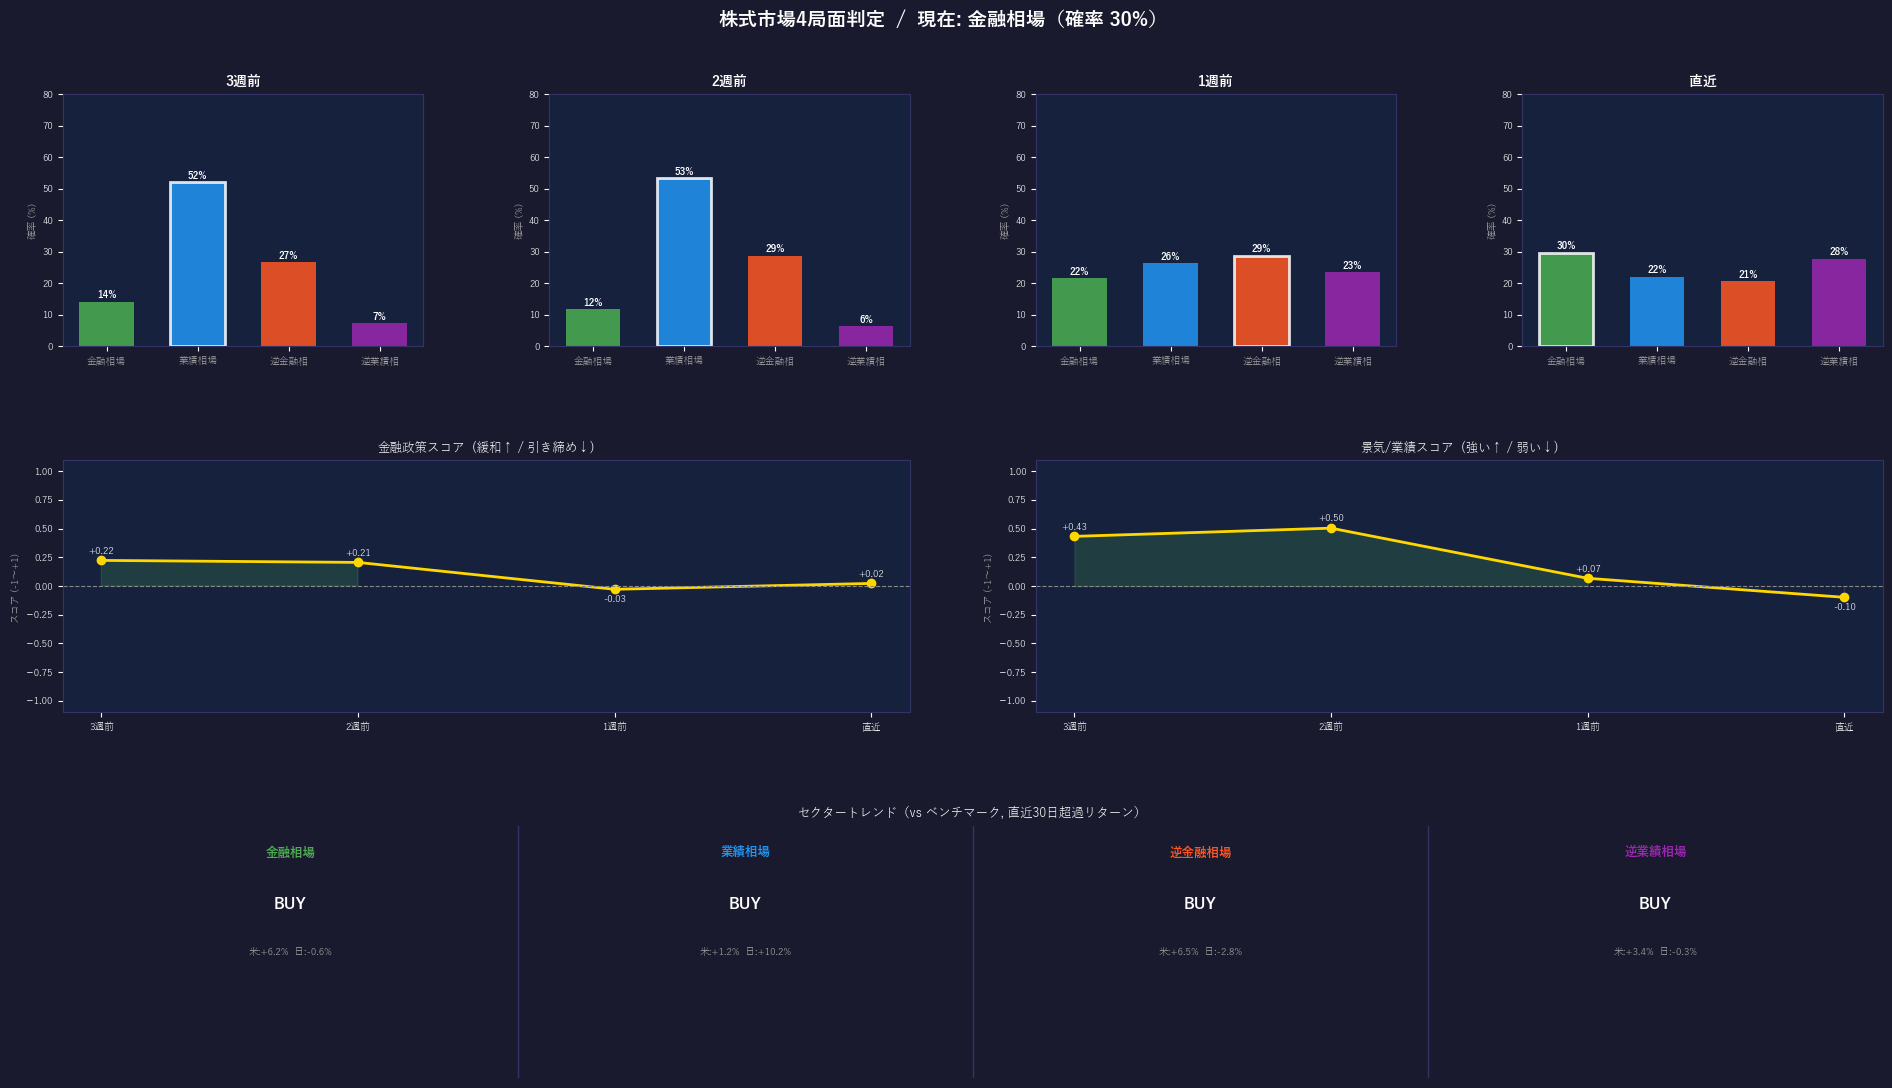

## 現在の最有力局面: 金融相場（確率 30%）

局面推移: **業績相場 -> 業績相場 -> 逆金融相場 -> 金融相場**
「業績相場」から「金融相場」への移行の兆しが見られます。

### 各局面の確率変化
| 局面 | 3週前 | 直近 | 変化 |
|------|-------|------|------|
| **金融相場** | 14% | 30% | ↑ +15% |
| 業績相場 | 52% | 22% | ↓ -30% |
| 逆金融相場 | 27% | 21% | ↓ -6% |
| 逆業績相場 | 7% | 28% | ↑ +20% |

### 金融相場について
金融緩和・景気底打ち。**不動産・IT・グロース株**が優位。

注目: 「逆業績相場」の確率が **20% 上昇中**。次局面への移行シグナルに注意してください。

In [5]:
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor("#1a1a2e")
gs = GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35,
              top=0.90, bottom=0.08, left=0.06, right=0.97)

latest_probs = history[-1][1]
dominant = max(latest_probs, key=latest_probs.get)
fig.suptitle(
    "株式市場4局面判定  /  現在: " + dominant
    + "（確率 " + "{:.0%}".format(latest_probs[dominant]) + "）",
    color="white", fontsize=14, fontweight="bold", y=0.97,
)

# 上段: 4時点バーグラフ
for col, (label, probs) in enumerate(history):
    ax = fig.add_subplot(gs[0, col])
    ax.set_facecolor("#16213e")
    vals = [probs[p] * 100 for p in PHASE_NAMES]
    bars = ax.bar(PHASE_NAMES, vals, color=PHASE_COLORS, width=0.6, alpha=0.85)
    ax.set_ylim(0, 80)
    ax.set_title(label, color="white", fontsize=10, fontweight="bold")
    ax.tick_params(colors="white", labelsize=7)
    ax.set_xticklabels([p[:4] for p in PHASE_NAMES], color="#aaaaaa", fontsize=7)
    ax.set_ylabel("確率 (%)", color="#aaaaaa", fontsize=7)
    for spine in ax.spines.values():
        spine.set_color("#333366")
    for bar, val in zip(bars, vals):
        if val > 5:
            ax.text(
                bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                "{:.0f}%".format(val), ha="center", va="bottom",
                color="white", fontsize=7, fontweight="bold",
            )
    dom_idx = PHASE_NAMES.index(max(probs, key=probs.get))
    bars[dom_idx].set_edgecolor("white")
    bars[dom_idx].set_linewidth(2)

# 中段: スコア推移
labels_x = [h[0] for h in history]
x = list(range(len(history)))
for ax, scores, title, pos_lbl, neg_lbl in [
    (fig.add_subplot(gs[1, :2]), m_scores, "金融政策スコア", "緩和↑", "引き締め↓"),
    (fig.add_subplot(gs[1, 2:]), e_scores, "景気/業績スコア", "強い↑", "弱い↓"),
]:
    ax.set_facecolor("#16213e")
    ax.plot(x, scores, "o-", color="#FFD700", linewidth=2, markersize=6)
    ax.axhline(0, color="#888888", linestyle="--", linewidth=0.8)
    ax.fill_between(x, scores, 0, where=[s > 0  for s in scores], alpha=0.2, color="#4CAF50")
    ax.fill_between(x, scores, 0, where=[s <= 0 for s in scores], alpha=0.2, color="#FF5722")
    ax.set_ylim(-1.1, 1.1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels_x, color="#aaaaaa", fontsize=8)
    ax.tick_params(colors="white", labelsize=7)
    ax.set_title(title + "  (" + pos_lbl + " / " + neg_lbl + ")", color="white", fontsize=9)
    ax.set_ylabel("スコア (-1〜+1)", color="#aaaaaa", fontsize=7)
    for spine in ax.spines.values():
        spine.set_color("#333366")
    for i, s in enumerate(scores):
        ax.text(
            i, s + 0.05 * (1 if s >= 0 else -1), "{:+.2f}".format(s),
            ha="center", va="bottom" if s >= 0 else "top", color="white", fontsize=7,
        )

# 下段: セクタートレンド
ax_s = fig.add_subplot(gs[2, :])
ax_s.set_facecolor("#16213e")
ax_s.axis("off")
col_w = 1.0 / len(PHASE_NAMES)
for pi, phase in enumerate(PHASE_NAMES):
    info = sector_trends.get(phase, {})
    cx   = col_w * pi + col_w / 2
    ax_s.text(cx, 0.92, phase, ha="center", va="top",
              color=PHASE_COLORS[pi], fontsize=9, fontweight="bold", transform=ax_s.transAxes)
    ax_s.text(cx, 0.72, info.get("label", "FLAT"), ha="center", va="top",
              color="white", fontsize=11, fontweight="bold", transform=ax_s.transAxes)
    ax_s.text(
        cx, 0.52,
        "米:" + "{:+.1f}".format(info.get("us", 0)) + "%  日:" + "{:+.1f}".format(info.get("jp", 0)) + "%",
        ha="center", va="top", color="#aaaaaa", fontsize=7, transform=ax_s.transAxes,
    )
    if pi < len(PHASE_NAMES) - 1:
        ax_s.axvline(col_w * (pi + 1), color="#333366", linewidth=1)
ax_s.set_title("セクタートレンド（vs ベンチマーク, 直近30日超過リターン）",
               color="white", fontsize=9, pad=6)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ── チャート直後に解説 ───────────────────────────────────────────────────────
display(Markdown(generate_transition_commentary(history)))